Error: 0.021562617747516204


/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


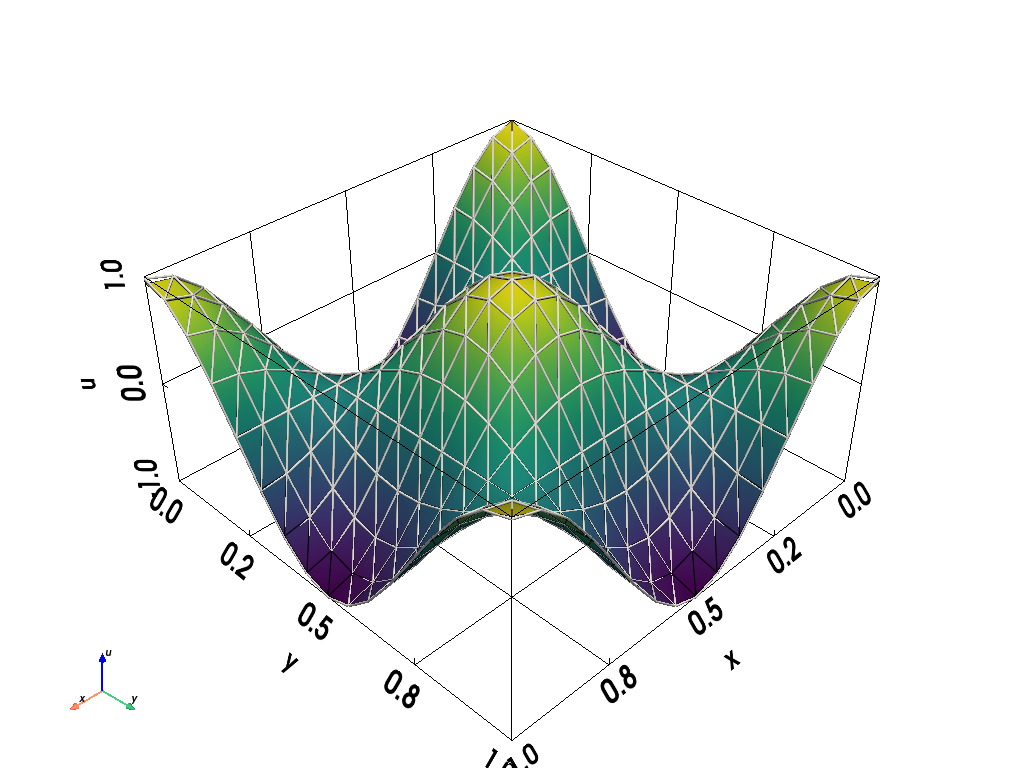

In [ ]:
# Part II: Pure Neumann BCs

# Fix MPI/OFI finalization errors on macOS
import os

os.environ["FI_PROVIDER"] = "tcp"
os.environ["MPICH_OFI_STARTUP_CONNECT"] = "0"

from mpi4py import MPI
import numpy as np
from petsc4py import PETSc
from dolfinx import mesh, fem, plot, io
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, LinearProblem
import ufl
import pyvista

# Mesh
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (1.0, 1.0)),
    n=(16, 16),
    cell_type=mesh.CellType.triangle,
)

# Function space
V = fem.functionspace(msh, ("CG", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Exact solution compatible with homogeneous Neumann (no-flux) BC
x = ufl.SpatialCoordinate(msh)
u_exact = ufl.cos(2.0 * np.pi * x[0]) * ufl.cos(2.0 * np.pi * x[1])
D = 0.5
f = -ufl.div(D*ufl.grad(u_exact)) + u_exact
g = fem.Constant(msh, PETSc.ScalarType(0.0))  # no-flux Neumann data du/dn = 0

# Weak form for pure Neumann problem
a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx  +  u * v * ufl.dx
L = f * v * ufl.dx + g * v * ufl.ds


# Problem
problem = LinearProblem(
    a,
    L,
    petsc_options_prefix="test_poisson_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_errorf_not_converged": True,
    },
)

uh = problem.solve()

l2_error = np.sqrt(fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx)))
print(f"Error: {l2_error}")


###############################
# Plotting with pyvista (3D)
###############################
cells, types, x = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")

u_exact_fun = fem.Function(V)
u_exact_fun.interpolate(lambda xx: np.cos(2.0 * np.pi * xx[0]) * np.cos(2.0 * np.pi * xx[1]))
grid_exact = pyvista.UnstructuredGrid(cells, types, x)
grid_exact.point_data["u_exact"] = u_exact_fun.x.array.real
grid_exact.set_active_scalars("u_exact")

warp_factor = 0.25
warped = grid.warp_by_scalar("u", factor=warp_factor)
warped_exact = grid_exact.warp_by_scalar("u_exact", factor=warp_factor)



plotter = pyvista.Plotter()
plotter.add_mesh(
    warped,
    scalars="u",
    cmap="viridis",
    show_scalar_bar=False,
    show_edges=True,
    edge_color="black",
    line_width=0.6,
    smooth_shading=True,
    lighting=True,
)
plotter.add_mesh(
    warped_exact,
    style="wireframe",
    color="white",
    line_width=2.4,
    render_lines_as_tubes=True,
    opacity=1.0,
)
z_min = float(np.min(grid.point_data["u"]))
z_max = float(np.max(grid.point_data["u"]))
plotter.show_bounds(grid="back", location="outer", all_edges=True, xtitle="x", ytitle="y", ztitle="u", font_size=25, n_zlabels=3, axes_ranges=[0.0, 1.0, 0.0, 1.0, z_min, z_max])
plotter.add_axes(xlabel="x", ylabel="y", zlabel="u")
plotter.view_isometric()
plotter.save_graphic("output/poisson_cg.pdf")
plotter.show()


with io.XDMFFile(msh.comm, "output/poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)

In [10]:
# Convergence test for pure Neumann problem (run after cell 1)
mesh_sizes = [8, 16, 32, 64]
hs = []
errors = []

for n_cells in mesh_sizes:
    # Mesh
    msh = mesh.create_rectangle(
        comm=MPI.COMM_WORLD,
        points=((0.0, 0.0), (1.0, 1.0)),
        n=(n_cells, n_cells),
        cell_type=mesh.CellType.triangle,
    )

    # Function space
    V = fem.functionspace(msh, ("CG", 1))
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)

    # Exact solution compatible with homogeneous Neumann (no-flux) BC
    x = ufl.SpatialCoordinate(msh)
    u_exact = ufl.cos(2.0 * np.pi * x[0]) * ufl.cos(2.0 * np.pi * x[1])
    D = 0.5
    f = -ufl.div(D*ufl.grad(u_exact)) + u_exact
    g = fem.Constant(msh, PETSc.ScalarType(0.0))  # no-flux Neumann data du/dn = 0

    # Weak form for pure Neumann problem
    a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx  +  u * v * ufl.dx
    L = f * v * ufl.dx + g * v * ufl.ds


    # Problem
    problem = LinearProblem(
        a,
        L,
        petsc_options_prefix="test_poisson_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "ksp_errorf_not_converged": True,
        },
    )

    uh = problem.solve()

    l2_error = np.sqrt(fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx)))
    print(f"Error: {l2_error}")

    hs.append(1.0 / n_cells)
    errors.append(l2_error)

if msh.comm.rank == 0:
    print("n        h        L2-error      rate")
    for i, (n_cells, h_i, e_i) in enumerate(zip(mesh_sizes, hs, errors)):
        if i == 0:
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {'-':>5}")
        else:
            rate_i = np.log(errors[i - 1] / e_i) / np.log(hs[i - 1] / h_i)
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {rate_i:>5.2f}")

Error: 0.07921009003804606
Error: 0.021562617747516204
Error: 0.005516819967505335
Error: 0.0013876713049802744
n        h        L2-error      rate
8        0.1250   7.9210e-02       -
16       0.0625   2.1563e-02    1.88
32       0.0312   5.5168e-03    1.97
64       0.0156   1.3877e-03    1.99


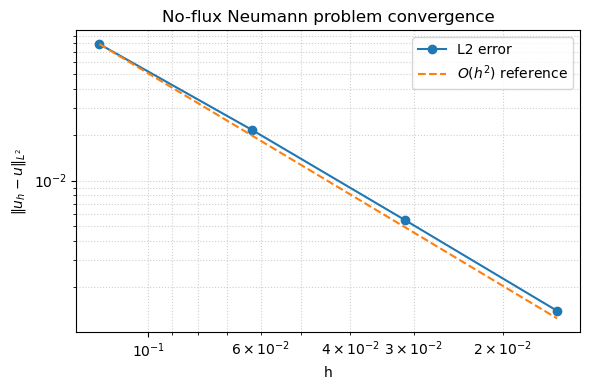

In [11]:
# Log-log convergence plot (run after cell 2)
import matplotlib.pyplot as plt

hs_arr = np.array(hs)
errors_arr = np.array(errors)

# Reference O(h^2) line anchored at first data point
ref = errors_arr[0] * (hs_arr / hs_arr[0])**2

plt.figure(figsize=(6, 4))
plt.loglog(hs_arr, errors_arr, "o-", label="L2 error")
plt.loglog(hs_arr, ref, "--", label=r"$O(h^2)$ reference")
plt.gca().invert_xaxis()
plt.xlabel("h")
plt.ylabel(r"$\|u_h - u\|_{L^2}$")
plt.title("No-flux Neumann problem convergence")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()